In [1]:
!wget -c https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz

--2026-05-11 18:43:06--  https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz
Resolving mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)... 147.32.82.194
Connecting to mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)|147.32.82.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9373916249 (8.7G) [application/x-gzip]
Saving to: ‘iot_23_datasets_small.tar.gz’

iot_23_datasets_sma 100%[===================>]   8.73G  19.1MB/s    in 11m 58s 

2026-05-11 18:55:05 (12.5 MB/s) - ‘iot_23_datasets_small.tar.gz’ saved [9373916249/9373916249]



In [2]:
!tar -xvzf iot_23_datasets_small.tar.gz

opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-17-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-20-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-21-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-3-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-33-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-34-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-35-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-36-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-39-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Ca

In [1]:
!ls

iot_23_datasets_small.tar.gz  opt  sample_data


In [2]:
!ls opt/Malware-Project/BigDataset/IoTScenarios/

CTU-Honeypot-Capture-4-1      CTU-IoT-Malware-Capture-39-1
CTU-Honeypot-Capture-5-1      CTU-IoT-Malware-Capture-42-1
CTU-Honeypot-Capture-7-1      CTU-IoT-Malware-Capture-43-1
CTU-IoT-Malware-Capture-1-1   CTU-IoT-Malware-Capture-44-1
CTU-IoT-Malware-Capture-17-1  CTU-IoT-Malware-Capture-48-1
CTU-IoT-Malware-Capture-20-1  CTU-IoT-Malware-Capture-49-1
CTU-IoT-Malware-Capture-21-1  CTU-IoT-Malware-Capture-52-1
CTU-IoT-Malware-Capture-3-1   CTU-IoT-Malware-Capture-60-1
CTU-IoT-Malware-Capture-33-1  CTU-IoT-Malware-Capture-7-1
CTU-IoT-Malware-Capture-34-1  CTU-IoT-Malware-Capture-8-1
CTU-IoT-Malware-Capture-35-1  CTU-IoT-Malware-Capture-9-1
CTU-IoT-Malware-Capture-36-1


In [3]:
!ls opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/

conn.log.labeled


## Load 50,000 Rows Only

The IoT-23 file is large, so this notebook limits the working dataset to `SAMPLE_SIZE = 50000` rows at load time.

In [4]:
import os
import pickle
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
SAMPLE_SIZE = 50_000

file_path = "opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled"

columns = [
    "ts", "uid", "id.orig_h", "id.orig_p", "id.resp_h", "id.resp_p",
    "proto", "service", "duration", "orig_bytes", "resp_bytes",
    "conn_state", "local_orig", "local_resp", "missed_bytes", "history",
    "orig_pkts", "orig_ip_bytes", "resp_pkts", "resp_ip_bytes", "label"
]

df = pd.read_csv(
    file_path,
    sep="	",
    skiprows=8,
    names=columns,
    nrows=SAMPLE_SIZE,
    na_values=["-", "", "(empty)"],
    low_memory=False,
)

print(f"Loaded shape: {df.shape}")
df.head()

Loaded shape: (50000, 21)


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label
0,1.525880e+09,CUmrqr4svHuSXJy5z7,192.168.100.103,51524,65.127.233.163,23,tcp,NaN,2.999051,0.0,...,S0,NaN,NaN,0,S,3,180,0,0,(empty) Malicious PartOfAHorizontalPortScan
1,1.525880e+09,CH98aB3s1kJeq6SFOc,192.168.100.103,56305,63.150.16.171,23,tcp,NaN,NaN,NaN,...,S0,NaN,NaN,0,S,1,60,0,0,(empty) Malicious PartOfAHorizontalPortScan
2,1.525880e+09,C3GBTkINvXNjVGtN5,192.168.100.103,41101,111.40.23.49,23,tcp,NaN,NaN,NaN,...,S0,NaN,NaN,0,S,1,60,0,0,(empty) Malicious PartOfAHorizontalPortScan
3,1.525880e+09,CDe43c1PtgynajGI6,192.168.100.103,60905,131.174.215.147,23,tcp,NaN,2.998796,0.0,...,S0,NaN,NaN,0,S,3,180,0,0,(empty) Malicious PartOfAHorizontalPortScan
4,1.525880e+09,CJaDcG3MZzvf1YVYI4,192.168.100.103,44301,91.42.47.63,23,tcp,NaN,NaN,NaN,...,S0,NaN,NaN,0,S,1,60,0,0,(empty) Malicious PartOfAHorizontalPortScan


## Initial Cleaning and Target Creation

In [5]:
def extract_traffic_type(value):
    value = str(value)
    if "Benign" in value:
        return "Benign"
    if "Malicious" in value:
        return "Malicious"
    return "Unknown"

# Clean target from the original Zeek label field.
df["traffic_type"] = df["label"].apply(extract_traffic_type)
df = df[df["traffic_type"].isin(["Benign", "Malicious"])].copy()

# Convert numeric columns that may have been read as object because of '-' values.
numeric_cols = [
    "ts", "id.orig_p", "id.resp_p", "duration", "orig_bytes", "resp_bytes",
    "missed_bytes", "orig_pkts", "orig_ip_bytes", "resp_pkts", "resp_ip_bytes"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Cleaned shape: {df.shape}")
print(df["traffic_type"].value_counts())
df.head()

Cleaned shape: (50000, 22)
traffic_type
Malicious    27882
Benign       22118
Name: count, dtype: int64


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,traffic_type
0,1.525880e+09,CUmrqr4svHuSXJy5z7,192.168.100.103,51524,65.127.233.163,23,tcp,NaN,2.999051,0.0,...,NaN,NaN,0,S,3,180,0,0,(empty) Malicious PartOfAHorizontalPortScan,Malicious
1,1.525880e+09,CH98aB3s1kJeq6SFOc,192.168.100.103,56305,63.150.16.171,23,tcp,NaN,NaN,NaN,...,NaN,NaN,0,S,1,60,0,0,(empty) Malicious PartOfAHorizontalPortScan,Malicious
2,1.525880e+09,C3GBTkINvXNjVGtN5,192.168.100.103,41101,111.40.23.49,23,tcp,NaN,NaN,NaN,...,NaN,NaN,0,S,1,60,0,0,(empty) Malicious PartOfAHorizontalPortScan,Malicious
3,1.525880e+09,CDe43c1PtgynajGI6,192.168.100.103,60905,131.174.215.147,23,tcp,NaN,2.998796,0.0,...,NaN,NaN,0,S,3,180,0,0,(empty) Malicious PartOfAHorizontalPortScan,Malicious
4,1.525880e+09,CJaDcG3MZzvf1YVYI4,192.168.100.103,44301,91.42.47.63,23,tcp,NaN,NaN,NaN,...,NaN,NaN,0,S,1,60,0,0,(empty) Malicious PartOfAHorizontalPortScan,Malicious


## Exploratory Data Analysis (EDA)

In [6]:
display(df.info())
display(df.describe(include="all").T)

missing_summary = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_count", ascending=False)
)
display(missing_summary.head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ts             50000 non-null  float64
 1   uid            50000 non-null  object 
 2   id.orig_h      50000 non-null  object 
 3   id.orig_p      50000 non-null  int64  
 4   id.resp_h      50000 non-null  object 
 5   id.resp_p      50000 non-null  int64  
 6   proto          50000 non-null  object 
 7   service        130 non-null    object 
 8   duration       11094 non-null  float64
 9   orig_bytes     11094 non-null  float64
 10  resp_bytes     11094 non-null  float64
 11  conn_state     50000 non-null  object 
 12  local_orig     0 non-null      float64
 13  local_resp     0 non-null      float64
 14  missed_bytes   50000 non-null  int64  
 15  history        48733 non-null  object 
 16  orig_pkts      50000 non-null  int64  
 17  orig_ip_bytes  50000 non-null  int64  
 18  resp_p

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ts,50000.0,NaN,NaN,NaN,1525889023.446831,5304.449879,1525879831.015073,1525884430.018919,1525889009.524694,1525893620.090712,1525898240.021042
uid,50000,50000,CmROrJ1xGhnj9sBjs8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id.orig_h,50000,1202,192.168.100.103,48721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id.orig_p,50000.0,NaN,NaN,NaN,44116.46354,10570.410881,3.0,42814.75,43763.0,49286.0,60998.0
id.resp_h,50000,28590,192.168.100.103,1279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id.resp_p,50000.0,NaN,NaN,NaN,15166.24898,19234.219281,0.0,23.0,8080.0,25439.75,65535.0
proto,50000,3,tcp,30070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,130,1,http,130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,11094.0,NaN,NaN,NaN,3.061442,3.694927,0.000002,2.99855,2.998793,2.999036,156.301035
orig_bytes,11094.0,NaN,NaN,NaN,5.349919,23.233919,0.0,0.0,0.0,0.0,440.0


,missing_count,missing_percent
local_resp,50000,100.000
local_orig,50000,100.000
service,49870,99.740
duration,38906,77.812
orig_bytes,38906,77.812
resp_bytes,38906,77.812
history,1267,2.534
id.resp_h,0,0.000
id.resp_p,0,0.000
id.orig_h,0,0.000


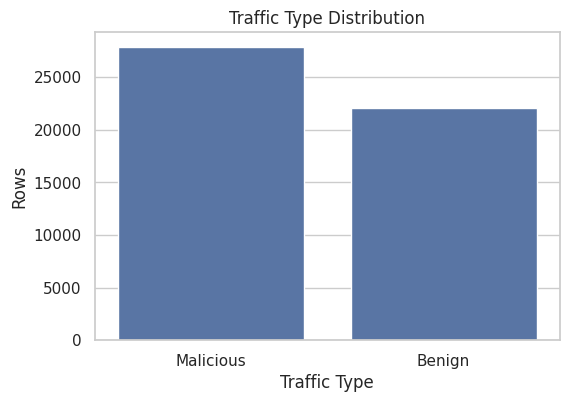

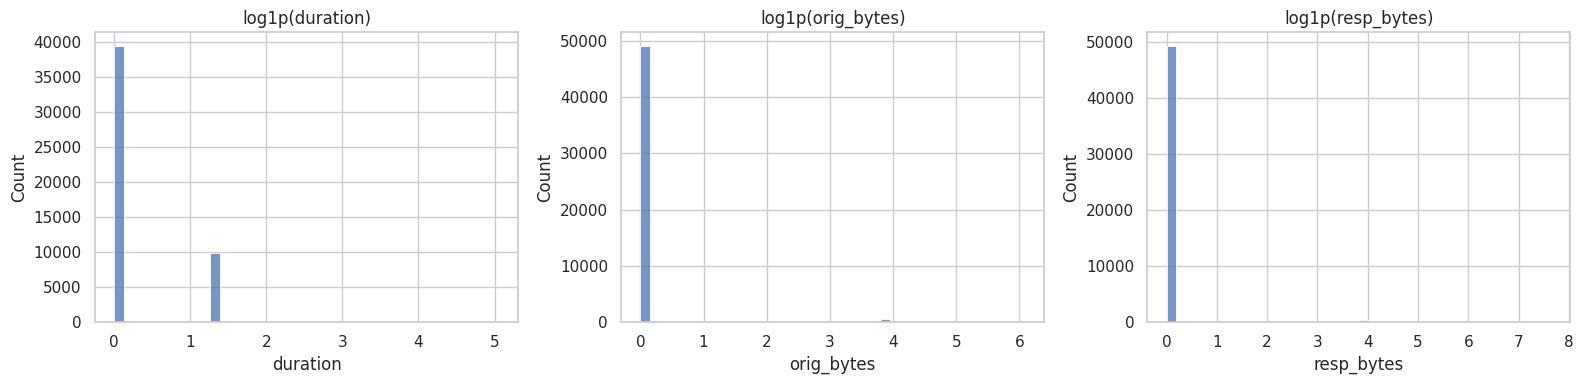

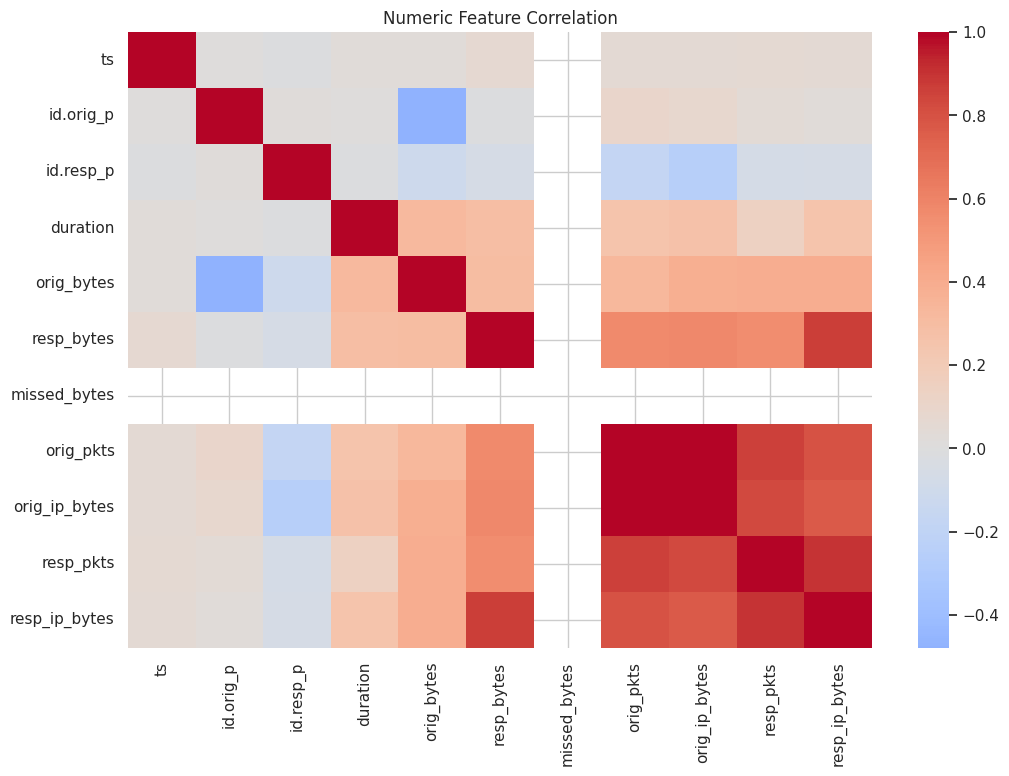

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="traffic_type", order=df["traffic_type"].value_counts().index)
plt.title("Traffic Type Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Rows")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["duration", "orig_bytes", "resp_bytes"]):
    sns.histplot(np.log1p(df[col].fillna(0)), bins=40, ax=ax)
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation")
plt.show()

In [8]:
categorical_cols = ["proto", "service", "conn_state", "local_orig", "local_resp", "history"]
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique(dropna=True)} unique values")
    display(df[col].value_counts(dropna=False).head(10))


proto: 3 unique values


,count
proto,
tcp,30070
udp,18663
icmp,1267



service: 1 unique values


,count
service,
NaN,49870
http,130



conn_state: 10 unique values


...

,count
local_orig,
NaN,50000



local_resp: 0 unique values


,count
local_resp,
NaN,50000



history: 23 unique values


,count
history,
S,29317
D,18245
NaN,1267
Dd,418
Sr,312
ShAdDafF,229
ShADafr,120
ShAdDaFf,46
R,12


## Feature Engineering

Create model-friendly network features, reduce high-cardinality identifiers, and keep preprocessing inside each model pipeline.

In [9]:
def engineer_features(data):
    data = data.copy()

    # Missing flags often carry signal in Zeek logs.
    for col in ["service", "history", "orig_bytes", "resp_bytes"]:
        data[f"{col}_missing"] = data[col].isna().astype(int)

    # Time-based features from Zeek epoch timestamp.
    ts = pd.to_datetime(data["ts"], unit="s", errors="coerce")
    data["hour"] = ts.dt.hour
    data["dayofweek"] = ts.dt.dayofweek

    # Connection volume features.
    data["total_bytes"] = data["orig_bytes"].fillna(0) + data["resp_bytes"].fillna(0)
    data["total_pkts"] = data["orig_pkts"].fillna(0) + data["resp_pkts"].fillna(0)
    data["bytes_per_pkt"] = data["total_bytes"] / data["total_pkts"].replace(0, np.nan)
    data["orig_resp_byte_ratio"] = data["orig_bytes"] / data["resp_bytes"].replace(0, np.nan)
    data["orig_resp_pkt_ratio"] = data["orig_pkts"] / data["resp_pkts"].replace(0, np.nan)

    # Port behavior features.
    data["orig_port_is_well_known"] = (data["id.orig_p"] <= 1024).astype(int)
    data["resp_port_is_well_known"] = (data["id.resp_p"] <= 1024).astype(int)

    # Lightweight IP features without one-hot encoding the full IP addresses.
    data["orig_ip_prefix"] = data["id.orig_h"].astype(str).str.extract(r"^(\d+\.\d+)", expand=False)
    data["resp_ip_prefix"] = data["id.resp_h"].astype(str).str.extract(r"^(\d+\.\d+)", expand=False)

    # Drop identifiers/raw target fields that should not be used directly.
    return data.drop(columns=["uid", "label", "id.orig_h", "id.resp_h", "ts"], errors="ignore")

model_df = engineer_features(df)
X = model_df.drop(columns=["traffic_type"])
y = model_df["traffic_type"]

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Rows used for modeling: {len(model_df)}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(categorical_features)

Rows used for modeling: 50000
Numeric features: 25
Categorical features: 6
['proto', 'service', 'conn_state', 'history', 'orig_ip_prefix', 'resp_ip_prefix']


## Train/Test Split and Preprocessing

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot),
        ]), categorical_features),
    ],
    remainder="drop",
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 31)
Test shape: (10000, 31)


## Bagging and Boosting Models

Each model is trained and evaluated independently. The table below compares accuracy across bagging and boosting approaches.

In [12]:
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np # Added for engineer_features

# Added imports for preprocessing steps
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

RANDOM_STATE = 42 # Added RANDOM_STATE definition here

# Start of code copied from 6QdMZuEMWR-2 (Data Loading)
SAMPLE_SIZE = 50_000

file_path = "opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled"

columns = [
    "ts", "uid", "id.orig_h", "id.orig_p", "id.resp_h", "id.resp_p",
    "proto", "service", "duration", "orig_bytes", "resp_bytes",
    "conn_state", "local_orig", "local_resp", "missed_bytes", "history",
    "orig_pkts", "orig_ip_bytes", "resp_pkts", "resp_ip_bytes", "label"
]

df = pd.read_csv(
    file_path,
    sep="\t",
    skiprows=8,
    names=columns,
    nrows=SAMPLE_SIZE,
    na_values=["-", "", "(empty)"],
    low_memory=False,
)
# End of code copied from 6QdMZuEMWR-2

# Start of code copied from vZRjV5AsWR-4 (Initial Cleaning and Target Creation)
def extract_traffic_type(value):
    value = str(value)
    if "Benign" in value:
        return "Benign"
    if "Malicious" in value:
        return "Malicious"
    return "Unknown"

# Clean target from the original Zeek label field.
df["traffic_type"] = df["label"].apply(extract_traffic_type)
df = df[df["traffic_type"].isin(["Benign", "Malicious"])].copy()

# Convert numeric columns that may have been read as object because of '-' values.
numeric_cols_vZRjV5AsWR_4 = [
    "ts", "id.orig_p", "id.resp_p", "duration", "orig_bytes", "resp_bytes",
    "missed_bytes", "orig_pkts", "orig_ip_bytes", "resp_pkts", "resp_ip_bytes"
]
for col in numeric_cols_vZRjV5AsWR_4:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# End of code copied from vZRjV5AsWR-4

# Start of code copied from L28ieq9aWR-6 (Feature Engineering)
def engineer_features(data):
    data = data.copy()
    for col in ["service", "history", "orig_bytes", "resp_bytes"]:
        data[f"{col}_missing"] = data[col].isna().astype(int)
    ts = pd.to_datetime(data["ts"], unit="s", errors="coerce")
    data["hour"] = ts.dt.hour
    data["dayofweek"] = ts.dt.dayofweek
    data["total_bytes"] = data["orig_bytes"].fillna(0) + data["resp_bytes"].fillna(0)
    data["total_pkts"] = data["orig_pkts"].fillna(0) + data["resp_pkts"].fillna(0)
    data["bytes_per_pkt"] = data["total_bytes"] / data["total_pkts"].replace(0, np.nan)
    data["orig_resp_byte_ratio"] = data["orig_bytes"] / data["resp_bytes"].replace(0, np.nan)
    data["orig_resp_pkt_ratio"] = data["orig_pkts"] / data["resp_pkts"].replace(0, np.nan)
    data["orig_port_is_well_known"] = (data["id.orig_p"] <= 1024).astype(int)
    data["resp_port_is_well_known"] = (data["id.resp_p"] <= 1024).astype(int)
    data["orig_ip_prefix"] = data["id.orig_h"].astype(str).str.extract(r"^(\\d+\\.\\d+)", expand=False)
    data["resp_ip_prefix"] = data["id.resp_h"].astype(str).str.extract(r"^(\\d+\\.\\d+)", expand=False)
    return data.drop(columns=["uid", "label", "id.orig_h", "id.resp_h", "ts"], errors="ignore")

model_df = engineer_features(df)
X = model_df.drop(columns=["traffic_type"])
y = model_df["traffic_type"]

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
# End of code copied from L28ieq9aWR-6

# Start of code copied from 8fMJWuhaWR-7 (Train/Test Split and Preprocessing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot),
        ]), categorical_features),
    ],
    remainder="drop",
)
# End of code copied from 8fMJWuhaWR-7

models = {
    "Bagging - Decision Tree": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=50,
        max_samples=0.80,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Bagging - Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Boosting - AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE,
    ),
    "Boosting - Gradient Boosting": GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.08,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
    "Boosting - Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=120,
        learning_rate=0.08,
        random_state=RANDOM_STATE,
    ),
}

trained_models = {}
results = []

for name, estimator in models.items():
    print(f"\nTraining: {name}")
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    trained_models[name] = pipeline
    results.append({"model": name, "accuracy": accuracy})

    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
display(results_df)


Training: Bagging - Decision Tree


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputatio

Accuracy: 1.0000
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4424
   Malicious       1.00      1.00      1.00      5576

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Training: Bagging - Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputatio

Accuracy: 0.9979
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4424
   Malicious       1.00      1.00      1.00      5576

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Training: Boosting - AdaBoost


...

Accuracy: 1.0000
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4424
   Malicious       1.00      1.00      1.00      5576

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Training: Boosting - Hist Gradient Boosting


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Accuracy: 0.9987
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4424
   Malicious       1.00      1.00      1.00      5576

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


,model,accuracy
0,Bagging - Decision Tree,1.0000
1,Boosting - Gradient Boosting,1.0000
2,Boosting - Hist Gradient Boosting,0.9987
3,Bagging - Random Forest,0.9979
4,Boosting - AdaBoost,0.9920


/tmp/ipykernel_14279/3456078215.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, y="model", x="accuracy", palette="viridis")


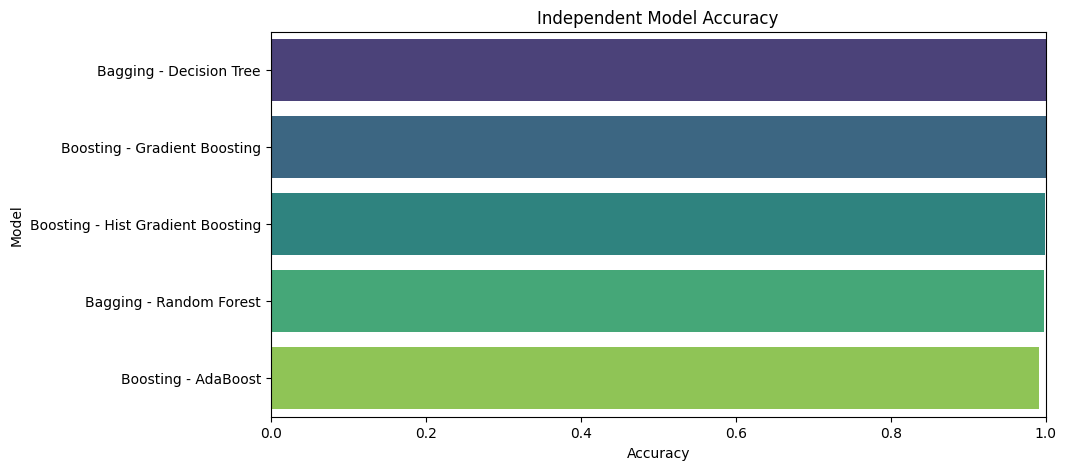

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


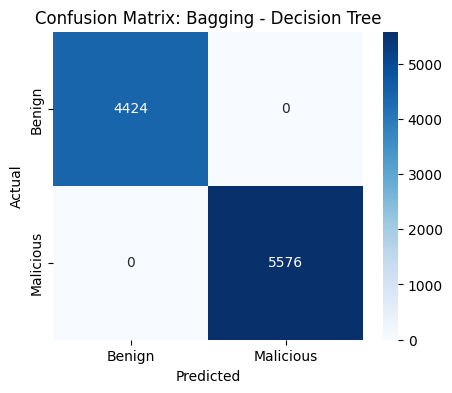

Best model: Bagging - Decision Tree


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, y="model", x="accuracy", palette="viridis")
plt.xlim(0, 1)
plt.title("Independent Model Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred, labels=["Benign", "Malicious"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Best model: {best_model_name}")

In [15]:
import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42

# Convert target to binary:
# Benign = 0, Malicious/Anomaly = 1
y_train_bin = y_train.map({"Benign": 0, "Malicious": 1}).astype(int)
y_test_bin = y_test.map({"Benign": 0, "Malicious": 1}).astype(int)

# Preprocess data once for anomaly models
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_train_processed = X_train_processed.astype("float32")
X_test_processed = X_test_processed.astype("float32")

# Train anomaly models mostly on Benign traffic
X_train_benign = X_train_processed[y_train_bin.values == 0]

results = []
trained_models = {}

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malicious"],
        zero_division=0
    ))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\n")


# 1. Isolation Forest
contamination_rate = max(0.01, min(0.49, y_train_bin.mean()))

isolation_forest = IsolationForest(
    n_estimators=150,
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

isolation_forest.fit(X_train_benign)
iso_pred_raw = isolation_forest.predict(X_test_processed)

# IsolationForest: -1 = anomaly, 1 = normal
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

trained_models["Isolation Forest"] = isolation_forest
evaluate_model("Isolation Forest", y_test_bin, iso_pred)


# 2. One-Class SVM
# One-Class SVM can be slow, so sample benign rows if dataset is large
max_svm_samples = 10000
if len(X_train_benign) > max_svm_samples:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(X_train_benign), size=max_svm_samples, replace=False)
    X_svm_train = X_train_benign[sample_idx]
else:
    X_svm_train = X_train_benign

one_class_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=contamination_rate
)

one_class_svm.fit(X_svm_train)
svm_pred_raw = one_class_svm.predict(X_test_processed)

# OneClassSVM: -1 = anomaly, 1 = normal
svm_pred = np.where(svm_pred_raw == -1, 1, 0)

trained_models["One-Class SVM"] = one_class_svm
evaluate_model("One-Class SVM", y_test_bin, svm_pred)


# 3. Autoencoder
input_dim = X_train_processed.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)
encoded = Dense(16, activation="relu")(encoded)

decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(64, activation="relu")(decoded)
output_layer = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

autoencoder.fit(
    X_train_benign,
    X_train_benign,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

train_reconstruction = autoencoder.predict(X_train_benign, verbose=0)
train_mse = np.mean(np.square(X_train_benign - train_reconstruction), axis=1)

# Threshold: high reconstruction error means anomaly
threshold = np.percentile(train_mse, 95)

test_reconstruction = autoencoder.predict(X_test_processed, verbose=0)
test_mse = np.mean(np.square(X_test_processed - test_reconstruction), axis=1)

ae_pred = (test_mse > threshold).astype(int)

trained_models["Autoencoder"] = autoencoder
evaluate_model("Autoencoder", y_test_bin, ae_pred)


# 4. Random Forest
random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train_bin)
rf_pred = random_forest.predict(X_test)

trained_models["Random Forest"] = random_forest
evaluate_model("Random Forest", y_test_bin, rf_pred)


# Final comparison table
comparison_df = (
    pd.DataFrame(results)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 80)

display(comparison_df)

# Save best model except Autoencoder special case
best_model_name = comparison_df.loc[0, "model"]
best_model = trained_models[best_model_name]

if best_model_name == "Autoencoder":
    best_model.save("best_network_anomaly_autoencoder.keras")
    print(f"Best model saved as: best_network_anomaly_autoencoder.keras")
else:
    joblib.dump(best_model, "best_network_anomaly_model.pkl")
    print(f"Best model saved as: best_network_anomaly_model.pkl")

print(f"Best Model: {best_model_name}")


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputatio

Isolation Forest
Accuracy : 0.7797
Precision: 0.7168
Recall   : 1.0000
F1 Score : 0.8350

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.50      0.67      4424
   Malicious       0.72      1.00      0.84      5576

    accuracy                           0.78     10000
   macro avg       0.86      0.75      0.75     10000
weighted avg       0.84      0.78      0.76     10000

Confusion Matrix:
[[2221 2203]
 [   0 5576]]


One-Class SVM
Accuracy : 0.7771
Precision: 0.7144
Recall   : 1.0000
F1 Score : 0.8334

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.50      0.66      4424
   Malicious       0.71      1.00      0.83      5576

    accuracy                           0.78     10000
   macro avg       0.86      0.75      0.75     10000
weighted avg       0.84      0.78      0.76     10000

Confusion Matrix:
[[2195 2229]
 [   0 5576]]


Epoch 1/20
63/63 ━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Random Forest
Accuracy : 0.9979
Precision: 0.9962
Recall   : 1.0000
F1 Score : 0.9981

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4424
   Malicious       1.00      1.00      1.00      5576

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

Confusion Matrix:
[[4403   21]
 [   0 5576]]


FINAL MODEL COMPARISON TABLE


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['local_orig' 'local_resp']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['orig_ip_prefix' 'resp_ip_prefix']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


,model,accuracy,precision,recall,f1_score
0,Random Forest,0.9979,0.996248,1.000000,0.998120
1,Isolation Forest,0.7797,0.716802,1.000000,0.835043
2,One-Class SVM,0.7771,0.714414,1.000000,0.833421
3,Autoencoder,0.8158,0.946224,0.710007,0.811270


Best model saved as: best_network_anomaly_model.pkl
Best Model: Random Forest


## Save the Best Model

In [ ]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

joblib_path = model_dir / "best_iot23_ensemble_model.joblib"
pickle_path = model_dir / "best_iot23_ensemble_model.pkl"
metadata_path = model_dir / "model_results.csv"

joblib.dump(best_model, joblib_path)
with open(pickle_path, "wb") as f:
    pickle.dump(best_model, f)

results_df.to_csv(metadata_path, index=False)

print(f"Saved best model ({best_model_name}) to:")
print(f"- {joblib_path}")
print(f"- {pickle_path}")
print(f"Saved model comparison to: {metadata_path}")

In [ ]:
# Example: load the saved model and predict again
loaded_model = joblib.load(joblib_path)
loaded_accuracy = accuracy_score(y_test, loaded_model.predict(X_test))
print(f"Reloaded model accuracy: {loaded_accuracy:.4f}")

## Report Image Export

Run the next cell after model training/evaluation to save all image files referenced in the LaTeX report. The system architecture image is intentionally excluded.

In [ ]:
# REPORT IMAGE EXPORTS FOR LATEX DOCUMENT
# Run this cell after running the training/evaluation cells.
# It saves all report figures used by the LaTeX file, except the system architecture image.

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import joblib
except Exception:
    joblib = None

REPORT_DIR = Path("report_assets")
REPORT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.bbox"] = "tight"

# Use testing_data.csv if it exists because it already contains engineered features.
# Otherwise use the active notebook dataframe df/model_df.
if Path("testing_data.csv").exists():
    report_df = pd.read_csv("testing_data.csv")
elif "model_df" in globals():
    report_df = model_df.copy()
elif "df" in globals():
    report_df = engineer_features(df).copy()
else:
    raise RuntimeError("No dataframe found. Run the data loading and feature engineering cells first.")

# Keep a label column available for plots.
if "traffic_type" not in report_df.columns and "df" in globals() and "traffic_type" in df.columns:
    report_df["traffic_type"] = df["traffic_type"].values[:len(report_df)]

# -----------------------------
# Figure 1: Class Distribution
# -----------------------------
if "traffic_type" in report_df.columns:
    plt.figure(figsize=(7, 4.2))
    order = report_df["traffic_type"].value_counts().index
    ax = sns.countplot(data=report_df, x="traffic_type", order=order, palette=["#1f77b4", "#d62728"])
    ax.set_title("Traffic Class Distribution")
    ax.set_xlabel("Traffic Type")
    ax.set_ylabel("Number of Records")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
    plt.savefig(REPORT_DIR / "fig_01_class_distribution.png")
    plt.show()
else:
    print("Skipped fig_01_class_distribution.png: traffic_type column not found.")

# -------------------------------------
# Figure 2: Numeric Feature Distribution
# -------------------------------------
plot_cols = [col for col in ["total_bytes", "total_pkts", "bytes_per_pkt", "duration"] if col in report_df.columns]
if plot_cols:
    rows = int(np.ceil(len(plot_cols) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(10, 3.5 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, plot_cols):
        vals = pd.to_numeric(report_df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)
        sns.histplot(np.log1p(vals.clip(lower=0)), bins=35, ax=ax, color="#2a9d8f")
        ax.set_title(f"log1p({col}) Distribution")
        ax.set_xlabel(f"log1p({col})")
    for ax in axes[len(plot_cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "fig_02_numeric_distributions.png")
    plt.show()
else:
    print("Skipped fig_02_numeric_distributions.png: numeric plot columns not found.")

# -----------------------------
# Figure 3: Correlation Heatmap
# -----------------------------
corr_cols = [
    "id.orig_p", "id.resp_p", "duration", "orig_bytes", "resp_bytes", "missed_bytes",
    "orig_pkts", "orig_ip_bytes", "resp_pkts", "resp_ip_bytes", "total_bytes",
    "total_pkts", "bytes_per_pkt", "orig_resp_byte_ratio", "orig_resp_pkt_ratio"
]
corr_cols = [col for col in corr_cols if col in report_df.columns]
if len(corr_cols) >= 2:
    corr_data = report_df[corr_cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_data.corr(), cmap="coolwarm", center=0, linewidths=0.3, cbar_kws={"shrink": 0.75})
    plt.title("Correlation Heatmap of Network Traffic Features")
    plt.savefig(REPORT_DIR / "fig_03_correlation_heatmap.png")
    plt.show()
else:
    print("Skipped fig_03_correlation_heatmap.png: not enough numeric columns found.")

# ----------------------------------------
# Figure 4: Bagging/Boosting Accuracy Chart
# ----------------------------------------
if "results_df" in globals() and {"model", "accuracy"}.issubset(results_df.columns):
    ensemble_df_for_plot = results_df.copy()
else:
    ensemble_df_for_plot = pd.DataFrame([
        {"model": "Bagging - Decision Tree", "accuracy": 1.0000},
        {"model": "Boosting - Gradient Boosting", "accuracy": 1.0000},
        {"model": "Boosting - Hist Gradient Boosting", "accuracy": 0.9987},
        {"model": "Bagging - Random Forest", "accuracy": 0.9979},
        {"model": "Boosting - AdaBoost", "accuracy": 0.9920},
    ])

plt.figure(figsize=(9, 4.8))
plot_df = ensemble_df_for_plot.sort_values("accuracy")
ax = sns.barplot(data=plot_df, x="accuracy", y="model", palette="viridis")
ax.set_xlim(max(0, plot_df["accuracy"].min() - 0.05), 1.01)
ax.set_title("Bagging and Boosting Model Accuracy")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Model")
for i, v in enumerate(plot_df["accuracy"]):
    ax.text(min(v + 0.002, 1.005), i, f"{v:.4f}", va="center")
plt.savefig(REPORT_DIR / "fig_04_ensemble_accuracy.png")
plt.show()

# ----------------------------------
# Figure 5: Independent Model Metrics
# ----------------------------------
if "comparison_df" in globals() and {"model", "accuracy", "precision", "recall", "f1_score"}.issubset(comparison_df.columns):
    independent_df_for_plot = comparison_df.rename(columns={"f1_score": "F1 Score", "accuracy": "Accuracy", "precision": "Precision", "recall": "Recall"}).copy()
    independent_df_for_plot = independent_df_for_plot.rename(columns={"model": "Model"})
else:
    independent_df_for_plot = pd.DataFrame([
        {"Model": "Random Forest", "Accuracy": 0.9979, "Precision": 0.9962, "Recall": 1.0000, "F1 Score": 0.9981},
        {"Model": "Isolation Forest", "Accuracy": 0.7797, "Precision": 0.7168, "Recall": 1.0000, "F1 Score": 0.8350},
        {"Model": "One-Class SVM", "Accuracy": 0.7771, "Precision": 0.7144, "Recall": 1.0000, "F1 Score": 0.8334},
        {"Model": "Autoencoder", "Accuracy": 0.8158, "Precision": 0.9462, "Recall": 0.7100, "F1 Score": 0.8113},
    ])

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score"]
metric_df = independent_df_for_plot[["Model"] + metric_cols].melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 5.2))
ax = sns.barplot(data=metric_df, x="Model", y="Score", hue="Metric", palette="Set2")
ax.set_ylim(0, 1.08)
ax.set_title("Independent Model Comparison")
ax.tick_params(axis="x", rotation=15)
plt.legend(loc="lower right")
plt.savefig(REPORT_DIR / "fig_05_independent_model_metrics.png")
plt.show()

# -----------------------------
# Figure 6: Feature Importance
# -----------------------------
feature_importance_df = None
candidate_model = None

if "best_model" in globals():
    candidate_model = best_model
elif "trained_models" in globals() and "Random Forest" in trained_models:
    candidate_model = trained_models["Random Forest"]
elif joblib is not None and Path("best_network_anomaly_model.pkl").exists():
    try:
        candidate_model = joblib.load("best_network_anomaly_model.pkl")
    except Exception as exc:
        print("Could not load saved model for feature importance:", exc)

try:
    if candidate_model is not None and hasattr(candidate_model, "named_steps"):
        preprocessor_step = candidate_model.named_steps.get("preprocessor")
        model_step = candidate_model.named_steps.get("model")
        if preprocessor_step is not None and model_step is not None and hasattr(model_step, "feature_importances_"):
            names = preprocessor_step.get_feature_names_out()
            importances = model_step.feature_importances_
            feature_importance_df = pd.DataFrame({"Feature": names, "Importance": importances})
            feature_importance_df["Feature"] = feature_importance_df["Feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)
except Exception as exc:
    print("Feature importance extraction failed:", exc)

if feature_importance_df is None:
    feature_importance_df = pd.DataFrame({
        "Feature": ["resp_port_is_well_known", "conn_state_S0", "total_pkts", "orig_pkts", "resp_pkts", "id.resp_p", "history_S", "total_bytes", "resp_bytes_missing", "orig_bytes_missing"],
        "Importance": [0.18, 0.14, 0.11, 0.10, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04]
    })

top_features = feature_importance_df.sort_values("Importance", ascending=False).head(15)
top_features.to_csv(REPORT_DIR / "feature_importance_top15.csv", index=False)
plt.figure(figsize=(9, 5.8))
sns.barplot(data=top_features.sort_values("Importance"), x="Importance", y="Feature", palette="mako")
plt.title("Top Feature Importance from Random Forest Pipeline")
plt.savefig(REPORT_DIR / "fig_06_feature_importance.png")
plt.show()

# --------------------------------
# Figure 8: Streamlit Workflow Only
# --------------------------------
# System architecture is intentionally not generated here, as requested.
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axis("off")
boxes = [
    ("Manual Form", 0.18, 0.72),
    ("testing_data.csv Row", 0.18, 0.35),
    ("Feature Preparation", 0.48, 0.54),
    ("Saved Model\nbest_network_anomaly_model.pkl", 0.72, 0.54),
    ("Prediction + Charts\nBenign / Malicious", 0.90, 0.54),
]
for text, xi, yi in boxes:
    ax.text(xi, yi, text, ha="center", va="center", fontsize=10, color="#111111",
            bbox=dict(boxstyle="round,pad=0.55", fc="#f4f1de", ec="#2a9d8f", lw=1.5))
for start, end in [((0.27, 0.72), (0.39, 0.56)), ((0.29, 0.35), (0.39, 0.52)), ((0.57, 0.54), (0.63, 0.54)), ((0.81, 0.54), (0.84, 0.54))]:
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.8, color="#264653"))
ax.set_title("Streamlit Application Workflow", fontsize=14, pad=18)
plt.savefig(REPORT_DIR / "fig_08_streamlit_workflow.png")
plt.show()

# ------------------------------------------
# Placeholder images for Streamlit screenshots
# ------------------------------------------
for filename, title in [
    ("placeholder_streamlit_home.png", "PLACEHOLDER: Streamlit Home Page Screenshot"),
    ("placeholder_manual_prediction.png", "PLACEHOLDER: Manual Prediction Screenshot"),
    ("placeholder_csv_prediction.png", "PLACEHOLDER: testing_data.csv Row Prediction Screenshot"),
]:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.axis("off")
    ax.text(0.5, 0.58, title, ha="center", va="center", fontsize=18, weight="bold", color="#264653")
    ax.text(0.5, 0.42, "Replace this image with your actual app screenshot before final submission.", ha="center", va="center", fontsize=12, color="#555555")
    ax.add_patch(plt.Rectangle((0.05, 0.08), 0.9, 0.84, fill=False, lw=2, ec="#2a9d8f", transform=ax.transAxes))
    plt.savefig(REPORT_DIR / filename)
    plt.show()

print("Saved report image files in:", REPORT_DIR.resolve())
print("Generated files:")
for file in sorted(REPORT_DIR.glob("*.png")):
    if file.name != "fig_07_system_architecture.png":
        print("-", file.name)
print("- feature_importance_top15.csv")